# Wavefront and atmosphere

**Scientific question.** What does a single frozen-flow von Kármán turbulence
realization look like across a telescope pupil, and how do the two ways the
library represents an aberration — optical path difference (OPD, in metres)
and phase (in radians at a reference wavelength) — relate to each other?

This tutorial uses only installed `shwfs_ao` APIs. It builds a pupil, draws one
seeded atmospheric screen, and confirms the phase/OPD conversion is an exact
inverse pair.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
)
from shwfs_ao.core.geometry import build_pupil_geometry
from shwfs_ao.core.wavefront import masked_rms, opd_to_phase, phase_to_opd

SEED = 20240517
TELESCOPE_DIAMETER_M = 2.0
PUPIL_PIXELS = 96
REFERENCE_WAVELENGTH_M = 500e-9

## Configuration

In [2]:
pupil = build_pupil_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(PUPIL_PIXELS, PUPIL_PIXELS),
)
config = FrozenFlowAtmosphereConfig(
    grid_size=PUPIL_PIXELS,
    delta_m=pupil.pixel_spacing_xy_m[0],
    pupil_diameter_m=TELESCOPE_DIAMETER_M,
    r0_m=0.15,
    outer_scale_m=25.0,
    wind_m_per_s=(8.0, 0.0),
    root_seed=SEED,
)
config

FrozenFlowAtmosphereConfig(grid_size=96, delta_m=0.021052631578947323, pupil_diameter_m=2.0, r0_m=0.15, outer_scale_m=25.0, phase_reference_wavelength_m=5e-07, wind_m_per_s=(8.0, 0.0), root_seed=20240517, target_rms_rad=None, normalize_rms=True)

## Simulation call

In [3]:
atmosphere = FrozenFlowAtmosphere(config, pupil_mask=pupil.pupil_mask)
atmosphere.reset(realization_index=0)
opd_m = atmosphere.opd_at(0.0)
phase_rad = opd_to_phase(opd_m, REFERENCE_WAVELENGTH_M)
opd_roundtrip_m = phase_to_opd(phase_rad, REFERENCE_WAVELENGTH_M)

## Diagnostic table

In [4]:
import pandas as pd

opd_rms_m = masked_rms(opd_m, pupil.pupil_mask)
table = pd.DataFrame(
    [
        ("Fried parameter r0", config.r0_m, "m"),
        ("Outer scale L0", config.outer_scale_m, "m"),
        ("D / r0", TELESCOPE_DIAMETER_M / config.r0_m, "-"),
        ("Screen OPD RMS", opd_rms_m * 1e9, "nm"),
        ("Screen phase RMS", masked_rms(phase_rad, pupil.pupil_mask), "rad"),
        (
            "Phase/OPD round-trip max error",
            float(np.nanmax(np.abs(opd_roundtrip_m - opd_m))),
            "m",
        ),
    ],
    columns=["quantity", "value", "units"],
)
table

,quantity,value,units
0,Fried parameter r0,1.500000e-01,m
1,Outer scale L0,2.500000e+01,m
2,D / r0,1.333333e+01,-
3,Screen OPD RMS,6.992906e+02,nm
4,Screen phase RMS,8.787545e+00,rad
5,Phase/OPD round-trip max error,2.117582e-22,m


## Plot

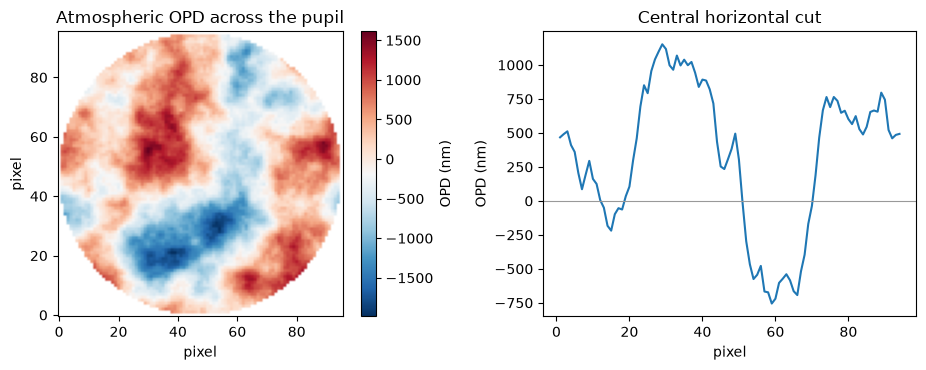

In [5]:
display_opd = np.where(pupil.pupil_mask, opd_m, np.nan) * 1e9
figure, (left, right) = plt.subplots(1, 2, figsize=(9.5, 3.8))
image = left.imshow(display_opd, origin="lower", cmap="RdBu_r")
left.set_title("Atmospheric OPD across the pupil")
left.set_xlabel("pixel")
left.set_ylabel("pixel")
figure.colorbar(image, ax=left, label="OPD (nm)")
mid_row = display_opd[PUPIL_PIXELS // 2]
right.plot(np.arange(PUPIL_PIXELS), mid_row, color="C0")
right.axhline(0.0, color="0.6", linewidth=0.8)
right.set_title("Central horizontal cut")
right.set_xlabel("pixel")
right.set_ylabel("OPD (nm)")
figure.tight_layout()
plt.show()

## Interpretation

The screen shows the smooth, large-scale structure expected of Kolmogorov
turbulence tempered by a finite outer scale: most power sits at low spatial
frequencies. With `D/r0` above ten, the RMS wavefront error is several hundred
nanometres — far more than a wavelength — which is exactly why adaptive
correction is needed. The phase and OPD representations carry identical
information: the round-trip conversion error is at the floating-point floor,
so downstream code may work in whichever unit is convenient.

## Limitations

- One realization at one instant; turbulence statistics require averaging over
  many seeds (see `studies/native_vs_hcipy.ipynb`).
- The frozen-flow model translates a single static screen; it does not model
  boiling or multi-layer profiles.
- The outer scale and `r0` are fixed illustrative values, not fitted to any
  specific site.